# 06 — RoomBeacon Shadow Validation

This notebook validates the already-locked **LightGBM Regressor / RAW / F4** champion under an inference-like contract. It never trains, tunes, benchmarks, or selects a model. Current known data is a `HISTORICAL_DRY_RUN`; only a wholly new post-lock batch may become `FUTURE_SHADOW` evidence.

## 01. Purpose and Contract

Responsibility boundary: Notebook 04 owns training and selection; Notebook 06 loads the immutable artifact, constructs the exact target-free F4 matrix, predicts, then—and only then—joins trusted actual rent for monitoring. Historical dry-run results verify mechanics and do not support a production claim.

## 02. Runtime Configuration

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json, platform, sys

PROJECT_ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'crawler').is_dir() and (p/'analytics').is_dir())
sys.path.insert(0,str(PROJECT_ROOT))

import duckdb,numpy as np,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display,Markdown
from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.shadow_validation import *
from notebooks.utils.modeling_benchmark import build_modeling_eligibility

SEED=42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
BENCHMARK_DIR=PROJECT_ROOT/'data'/'modeling'/'roombeacon_price_benchmark_v3'
SILVER_PATH=resolve_runtime_path(env.processing.silver_dir)/'rental_listings.parquet'
SHADOW_OUTPUT_ROOT=PROJECT_ROOT/'data'/'modeling'/'shadow_validation'
MIN_SUPPORT=100
INFERENCE_TIMESTAMP=datetime.now(timezone.utc).isoformat()
runtime=pd.Series({'Python':platform.python_version(),'Benchmark directory':str(BENCHMARK_DIR),'Silver path':str(SILVER_PATH),'Shadow output':str(SHADOW_OUTPUT_ROOT),'Minimum slice support':MIN_SUPPORT},name='Runtime')
display(runtime.to_frame())

,Runtime
Python,3.12.3
Benchmark directory,/data/projects/roombeacon/source/roombeacon-sy...
Silver path,/data/projects/roombeacon/source/roombeacon-sy...
Shadow output,/data/projects/roombeacon/source/roombeacon-sy...
Minimum slice support,100


## 03. Load Champion Artifact

In [2]:
champion=resolve_champion_artifact(BENCHMARK_DIR)
champion_summary=pd.Series({'model_id':champion.metadata['model_id'],'model family':champion.metadata['model_family'],'target transform':champion.metadata['target_transform'],'feature set':champion.metadata['feature_set'],'feature names':', '.join(champion.metadata['feature_names']),'parameters':json.dumps(champion.metadata['hyperparameters'],sort_keys=True),'random seed':champion.metadata['random_seed'],'artifact SHA-256':champion.metadata['artifact_sha256'],'reference population':champion.reference_profile['population'],'reference rows':champion.reference_profile['row_count'],'reference range':f"{champion.reference_profile['min_observed_at']} → {champion.reference_profile['max_observed_at']}"},name='Locked champion')
display(champion_summary.to_frame())

,Locked champion
model_id,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450
model family,LightGBM Regressor
target transform,RAW
feature set,F4 — AREA + SOURCE + LOCATION
feature names,"area_value_clean, source_code, ward_current, d..."
parameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
random seed,42
artifact SHA-256,0b0c9d9fa450fa6f969184c220fc06a9f5434e5cd44af9...
reference population,DEVELOPMENT
reference rows,95731


## 04. Load Canonical Silver / Shadow Batch

In [3]:
with duckdb.connect(':memory:') as connection:
    silver_df=connection.execute('SELECT * FROM read_parquet(?)',[str(SILVER_PATH)]).df()
assert len(silver_df)==silver_df.rental_post_id.nunique()
evidence_cutoff=champion.metadata['training_reference']['evidence_cutoff']
mode_decision=classify_validation_mode(silver_df.latest_observed_at,evidence_cutoff)
VALIDATION_MODE=mode_decision.mode
CURRENT_SILVER_SHA256=file_sha256(SILVER_PATH)
batch_summary=pd.Series({'Silver rows':len(silver_df),'Distinct rental_post_id':silver_df.rental_post_id.nunique(),'Silver SHA-256':CURRENT_SILVER_SHA256,'Minimum observed at':pd.to_datetime(silver_df.latest_observed_at).min(),'Maximum observed at':pd.to_datetime(silver_df.latest_observed_at).max(),'Model-lock evidence cutoff':evidence_cutoff,'Validation mode':VALIDATION_MODE,'Counts toward production evidence':mode_decision.counts_toward_production,'Mode reason':mode_decision.reason},name='Shadow batch')
display(batch_summary.to_frame())
if CURRENT_SILVER_SHA256==champion.metadata['training_reference']['silver_sha256']:
    assert VALIDATION_MODE=='HISTORICAL_DRY_RUN', 'The champion-development snapshot must remain a historical dry run'

,Shadow batch
Silver rows,132436
Distinct rental_post_id,132436
Silver SHA-256,123fae3a41bb62148649c6ede9c4e8164f1aadc9daed03...
Minimum observed at,2026-09-20 12:48:44
Maximum observed at,2026-09-30 10:42:53
Model-lock evidence cutoff,2026-09-30T10:42:53
Validation mode,HISTORICAL_DRY_RUN
Counts toward production evidence,False
Mode reason,Batch is historical or mixed relative to the m...


## 05. Validate Inference Schema

In [4]:
population=prepare_shadow_population(silver_df,champion.metadata,policy='PERMISSIVE')
display(population.funnel)
display(population.schema_summary)
display(population.all_rows.inference_status.value_counts(dropna=False).rename('Rows').to_frame())
assert len(population.all_rows)==len(silver_df)
assert len(population.ready_rows)==int(population.all_rows.inference_status.eq('READY_FOR_INFERENCE').sum())

,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132436,0,100.000000,PERMISSIVE
1,Area supported,130090,2346,98.228578,PERMISSIVE
2,Rental-compatible,129066,1024,97.455375,PERMISSIVE
3,Final inference eligible,129066,0,97.455375,PERMISSIVE
4,Inference-ready,129066,0,97.455375,PERMISSIVE


,Status,Reason,Rows
0,READY_FOR_INFERENCE,SCHEMA_VALID,129066


,Rows
inference_status,
READY_FOR_INFERENCE,129066
UNSUPPORTED,3370


## 06. Build F4 Features

In [5]:
X_shadow=build_inference_matrix(population.ready_rows,champion.metadata)
feature_contract=pd.DataFrame({'Position':range(1,len(X_shadow.columns)+1),'Feature':X_shadow.columns,'Runtime dtype':[str(dtype) for dtype in X_shadow.dtypes],'Expected type':[champion.metadata['expected_schema'][column] for column in X_shadow.columns]})
display(feature_contract)
assert X_shadow.columns.tolist()==champion.metadata['feature_names']==list(F4_FEATURES)
assert TARGET_COLUMN not in X_shadow.columns
assert len(X_shadow)==len(population.ready_rows)

,Position,Feature,Runtime dtype,Expected type
0,1,area_value_clean,float64,numeric
1,2,source_code,category,categorical
2,3,ward_current,category,categorical
3,4,district_text_extracted,category,categorical


## 07. Reference vs Shadow Population

,Stage,Rows,Context
0,1. Silver total snapshot,132436,Full cleaned crawl dataset
1,2. Inference-ready population,129066,Target-free physical & rental features
2,3. Evaluation-ready population,112226,Full target trust & room-suitability


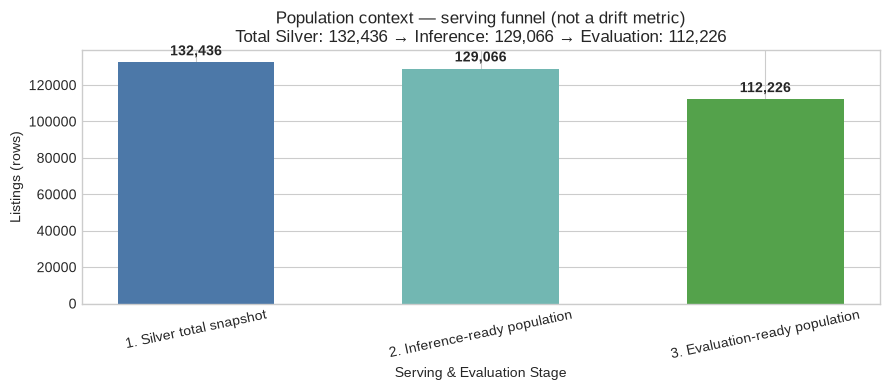

In [6]:
eval_rows_count=int(build_modeling_eligibility(silver_df,policy='PERMISSIVE').final_eligible.sum())
funnel_df=pd.DataFrame([{'Stage':'1. Silver total snapshot','Rows':len(silver_df),'Context':'Full cleaned crawl dataset'},{'Stage':'2. Inference-ready population','Rows':len(population.ready_rows),'Context':'Target-free physical & rental features'},{'Stage':'3. Evaluation-ready population','Rows':eval_rows_count,'Context':'Full target trust & room-suitability'}])
display(funnel_df)
fig,ax=plt.subplots(figsize=(9,4)); bars=ax.bar(funnel_df['Stage'],funnel_df['Rows'],color=['#4C78A8','#72B7B2','#54A24B'],width=0.55)
for bar in bars:
    height=bar.get_height()
    ax.annotate(f'{int(height):,}',xy=(bar.get_x()+bar.get_width()/2,height),xytext=(0,3),textcoords="offset points",ha='center',va='bottom',fontweight='bold')
ax.set(title=f'Population context — serving funnel (not a drift metric)\nTotal Silver: {len(silver_df):,} → Inference: {len(population.ready_rows):,} → Evaluation: {eval_rows_count:,}',ylabel='Listings (rows)',xlabel='Serving & Evaluation Stage')
ax.tick_params(axis='x',rotation=12); plt.tight_layout(); plt.show()

## 08. Feature Drift

,Feature,Reference Median,Shadow Median,Median Shift,Reference IQR,Shadow IQR,IQR Shift,Reference P95,Shadow P95,P95 Shift,Reference Missing %,Shadow Missing %,Missing Shift pp
0,area_value_clean,28.0,28.0,0.0,13.0,13.0,0.0,50.0,50.0,0.0,0.0,0.0,0.0


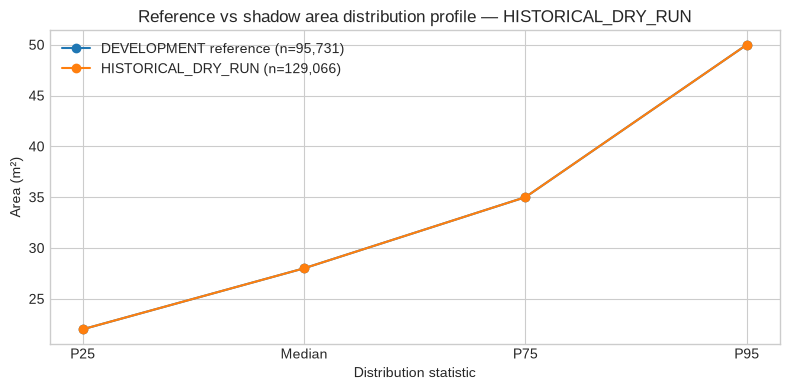

In [7]:
numeric_drift,category_share_drift=feature_drift_report(population.ready_rows,champion.reference_profile)
display(numeric_drift)
reference_area=champion.reference_profile['numeric']['area_value_clean']
shadow_area=population.ready_rows.area_value_clean.astype(float)
quantile_labels=['P25','Median','P75','P95']
reference_quantiles=[reference_area['p25'],reference_area['median'],reference_area['p75'],reference_area['p95']]
shadow_quantiles=[shadow_area.quantile(.25),shadow_area.median(),shadow_area.quantile(.75),shadow_area.quantile(.95)]
fig,ax=plt.subplots(figsize=(8,4)); x=np.arange(len(quantile_labels)); ax.plot(x,reference_quantiles,marker='o',label=f"DEVELOPMENT reference (n={champion.reference_profile['row_count']:,})"); ax.plot(x,shadow_quantiles,marker='o',label=f'{VALIDATION_MODE} (n={len(shadow_area):,})'); ax.set(xticks=x,xticklabels=quantile_labels,title=f'Reference vs shadow area distribution profile — {VALIDATION_MODE}',xlabel='Distribution statistic',ylabel='Area (m²)'); ax.legend(); plt.tight_layout(); plt.show()

## 09. Category Drift

,Feature,Reference Category Count,Shadow Category Count,Unseen Category Count,Unseen Categories,Unseen Rows,Unseen Row %,Reference Missing %,Shadow Missing %,Missing Shift pp
0,source_code,6,6,0,[],0,0.000000,0.000000,0.000000,0.000000
1,ward_current,78,78,0,[],0,0.000000,34.622014,32.902546,-1.719468
2,district_text_extracted,53,54,1,"[""Quận TB""]",1,0.000775,36.435428,34.141447,-2.293981


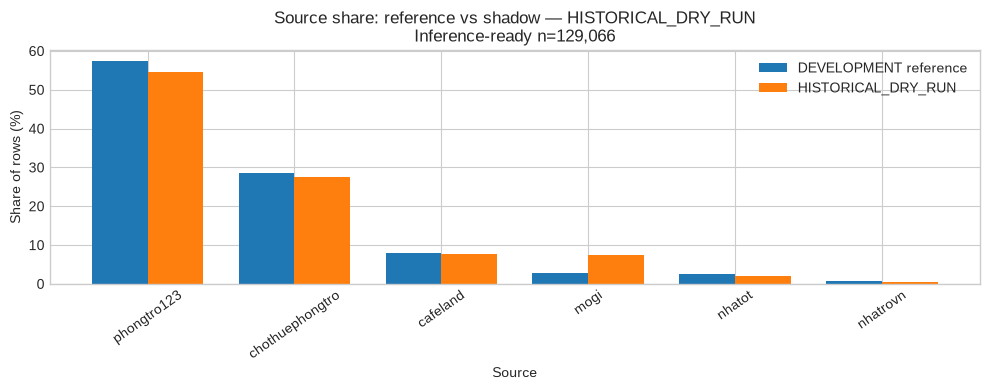

In [8]:
category_drift=category_drift_report(population.ready_rows,champion.reference_profile)
display(category_drift)
source_share=category_share_drift.loc[category_share_drift.Feature.eq('source_code')].sort_values('Reference Share %',ascending=False)
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(source_share)); width=.38; ax.bar(x-width/2,source_share['Reference Share %'],width,label='DEVELOPMENT reference'); ax.bar(x+width/2,source_share['Shadow Share %'],width,label=VALIDATION_MODE); ax.set(xticks=x,xticklabels=source_share.Category,title=f'Source share: reference vs shadow — {VALIDATION_MODE}\nInference-ready n={len(population.ready_rows):,}',xlabel='Source',ylabel='Share of rows (%)'); ax.tick_params(axis='x',rotation=35); ax.legend(); plt.tight_layout(); plt.show()

## 10. Run Shadow Inference

In [9]:
shadow_predictions=predict_shadow(champion.model,population.ready_rows,champion.metadata,VALIDATION_MODE,INFERENCE_TIMESTAMP)
display(shadow_predictions.head())
display(pd.Series({'Inference-ready rows':len(population.ready_rows),'Prediction rows':len(shadow_predictions),'Model ID':champion.metadata['model_id'],'Validation mode':VALIDATION_MODE,'Actual target present during prediction':TARGET_COLUMN in X_shadow.columns},name='Inference result').to_frame())
assert len(shadow_predictions)==len(population.ready_rows)
assert shadow_predictions.rental_post_id.tolist()==population.ready_rows.rental_post_id.tolist()

,rental_post_id,observed_at,area_value_clean,source_code,ward_current,district_text_extracted,predicted_monthly_rent,model_version,model_id,validation_mode,inference_timestamp
0,53598,2026-09-28 07:50:50,16.0,mogi,NaN,Quận 3,3.040911e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-05T06:50:41.340462+00:00
1,53599,2026-09-25 20:20:14,17.0,mogi,Phường Bàn Cờ,Quận 3,3.630393e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-05T06:50:41.340462+00:00
2,53600,2026-09-28 07:45:33,30.0,mogi,Phường Gia Định,Quận Bình Thạnh,4.990402e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-05T06:50:41.340462+00:00
3,53601,2026-09-28 09:44:50,35.0,mogi,NaN,Quận Tân Bình,3.835522e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-05T06:50:41.340462+00:00
4,53602,2026-09-28 09:44:50,30.0,mogi,NaN,Quận Tân Bình,3.850609e+06,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450,HISTORICAL_DRY_RUN,2026-10-05T06:50:41.340462+00:00


,Inference result
Inference-ready rows,129066
Prediction rows,129066
Model ID,roombeacon-price-lgbm-f4-raw-0b0c9d9fa450
Validation mode,HISTORICAL_DRY_RUN
Actual target present during prediction,False


## 11. Prediction Sanity

,Check,Status
0,Prediction count matches inference-ready rows,PASS
1,Prediction IDs are unique,PASS
2,No missing predictions,PASS
3,All predictions are finite,PASS
4,No negative predictions,PASS


,count,min,p01,p25,median,p75,p95,p99,max
0,129066,514492.913765,1.805112e+06,3.462905e+06,4.050359e+06,5.000002e+06,5.719635e+06,6.647404e+06,7.197122e+06


,Population,count,min,p01,p25,median,p75,p95,p99,max
0,DEVELOPMENT_REFERENCE,95731.0,514492.913765,1.841901e+06,3.462905e+06,4.050359e+06,5.000115e+06,5.699392e+06,6.588095e+06,7.197122e+06
1,HISTORICAL_DRY_RUN,129066.0,514492.913765,1.805112e+06,3.462905e+06,4.050359e+06,5.000002e+06,5.719635e+06,6.647404e+06,7.197122e+06


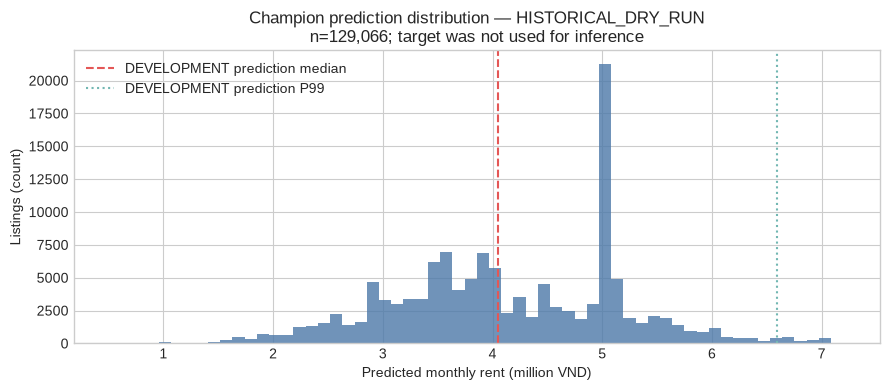

In [10]:
sanity_checks=prediction_sanity_report(shadow_predictions,len(population.ready_rows))
prediction_distribution_table=prediction_distribution(shadow_predictions)
reference_prediction=champion.reference_profile.get('prediction') or {}
prediction_reference_comparison=pd.DataFrame([{'Population':'DEVELOPMENT_REFERENCE',**reference_prediction},{'Population':VALIDATION_MODE,**prediction_distribution_table.iloc[0].to_dict()}])
display(sanity_checks); display(prediction_distribution_table); display(prediction_reference_comparison)
assert sanity_checks.Status.eq('PASS').all()
fig,ax=plt.subplots(figsize=(9,4)); ax.hist(shadow_predictions.predicted_monthly_rent/1_000_000,bins=60,color='#4C78A8',alpha=.8); reference_median=reference_prediction.get('median'); reference_p99=reference_prediction.get('p99');
if reference_median is not None: ax.axvline(reference_median/1_000_000,color='#E45756',linestyle='--',label='DEVELOPMENT prediction median')
if reference_p99 is not None: ax.axvline(reference_p99/1_000_000,color='#72B7B2',linestyle=':',label='DEVELOPMENT prediction P99')
ax.set(title=f'Champion prediction distribution — {VALIDATION_MODE}\nn={len(shadow_predictions):,}; target was not used for inference',xlabel='Predicted monthly rent (million VND)',ylabel='Listings (count)'); ax.legend(); plt.tight_layout(); plt.show()

## 12. Overall Error Metrics

,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132436,0,100.000000,PERMISSIVE
1,Numeric target candidate,128051,4385,96.688967,PERMISSIVE
2,Lineage trusted,118886,9165,89.768643,PERMISSIVE
3,Semantic target supported,114436,4450,86.408529,PERMISSIVE
4,Area supported,112226,2210,84.739799,PERMISSIVE
5,Rental-compatible,112226,0,84.739799,PERMISSIVE
6,Final model eligible,112226,0,84.739799,PERMISSIVE


,Reason,Rows
0,MODEL_ELIGIBLE,112226
1,TARGET_LINEAGE_NOT_TRUSTED,9165
2,PRICE_SEMANTIC_NOT_SUPPORTED,4450
3,NO_NUMERIC_TARGET_CANDIDATE,4385
4,AREA_NOT_SUPPORTED,2210


,Rows,MAE,MedianAE,RMSE,RMSLE,R²,Signed Bias,Underprediction %,Overprediction %,Exact Match %
0,112226,1.079060e+06,694609.867523,1.678178e+06,0.453572,0.271535,-43401.262431,49.742484,50.257516,0.0


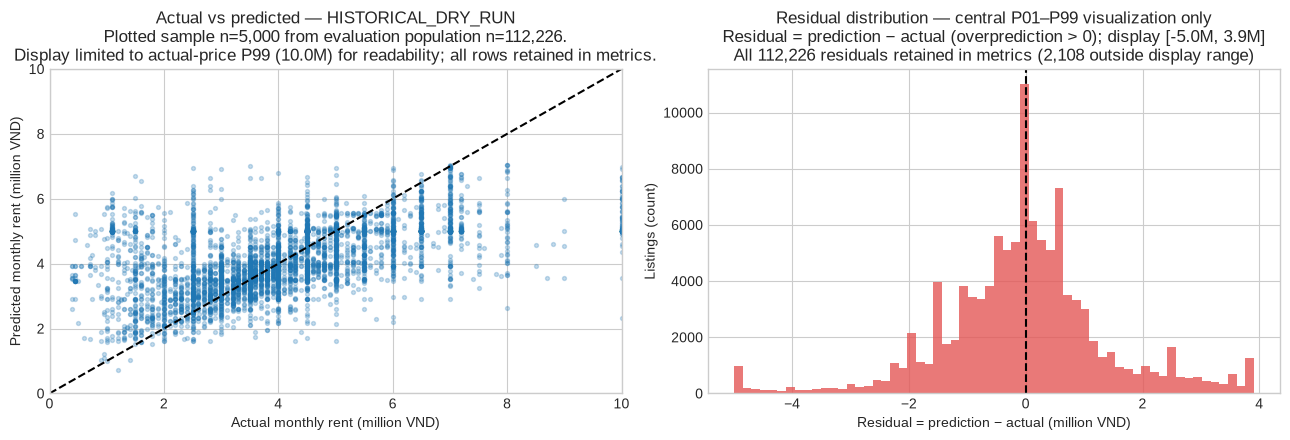

Residual distribution diagnostics: full min=-166,266,223 VND, full max=5,931,257 VND, central P01=-4,995,303 VND, central P99=3,909,890 VND, outside central display=2,108 rows (all retained in metrics).


In [11]:
evaluation_population=prepare_evaluation_population(shadow_predictions,silver_df,policy='PERMISSIVE',target_column=TARGET_COLUMN)
shadow_output=evaluation_population.all_predictions
evaluation_frame=evaluation_population.evaluation_predictions
display(evaluation_population.funnel)
display(evaluation_population.exclusion_summary)
assert len(shadow_output)==len(shadow_predictions)
assert len(evaluation_frame)==int(evaluation_population.funnel.loc[evaluation_population.funnel.Stage.eq('Final model eligible'),'Rows'].iloc[0])
overall_metrics=pd.DataFrame([evaluate_shadow_predictions(evaluation_frame)])
display(overall_metrics)
evaluated=evaluation_frame.loc[evaluation_frame.actual_monthly_rent.notna()].copy()
sample=evaluated.sample(min(5000,len(evaluated)),random_state=SEED) if len(evaluated) else evaluated
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
limit=evaluated.actual_monthly_rent.quantile(.99) if len(evaluated) else 1
axes[0].scatter(sample.actual_monthly_rent/1_000_000,sample.predicted_monthly_rent/1_000_000,s=8,alpha=.25)
axes[0].plot([0,limit/1_000_000],[0,limit/1_000_000],'--',color='black')
axes[0].set(xlim=(0,limit/1_000_000),ylim=(0,limit/1_000_000),title=f'Actual vs predicted — {VALIDATION_MODE}\nPlotted sample n={len(sample):,} from evaluation population n={len(evaluated):,}.\nDisplay limited to actual-price P99 ({limit/1e6:.1f}M) for readability; all rows retained in metrics.',xlabel='Actual monthly rent (million VND)',ylabel='Predicted monthly rent (million VND)')

p01_res=evaluated.residual.quantile(0.01)
p99_res=evaluated.residual.quantile(0.99)
central_mask=evaluated.residual.between(p01_res,p99_res)
central_res=evaluated.loc[central_mask,'residual']
outside_count=len(evaluated)-len(central_res)
axes[1].hist(central_res/1_000_000,bins=60,color='#E45756',alpha=.8)
axes[1].axvline(0,color='black',linestyle='--')
axes[1].set(title=f'Residual distribution — central P01–P99 visualization only\nResidual = prediction − actual (overprediction > 0); display [{p01_res/1e6:.1f}M, {p99_res/1e6:.1f}M]\nAll {len(evaluated):,} residuals retained in metrics ({outside_count:,} outside display range)',xlabel='Residual = prediction − actual (million VND)',ylabel='Listings (count)')
plt.tight_layout(); plt.show()
print(f"Residual distribution diagnostics: full min={evaluated.residual.min():,.0f} VND, full max={evaluated.residual.max():,.0f} VND, central P01={p01_res:,.0f} VND, central P99={p99_res:,.0f} VND, outside central display={outside_count:,} rows (all retained in metrics).")

## 13. Price-Bucket Diagnostics

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Actual Price Bucket,< 2.5M,17409,15.512448,1600000.0,3.245253e+06,1.819393e+06,1.515581e+06,1.801727e+06
1,Actual Price Bucket,2.5M–<4.0M,36549,32.567320,3200000.0,3.525735e+06,6.684811e+05,4.396703e+05,4.245825e+05
2,Actual Price Bucket,4.0M–<6.0M,39459,35.160302,4500000.0,4.470213e+06,6.343432e+05,5.046968e+05,-3.043291e+05
3,Actual Price Bucket,6.0M–10.0M,15934,14.198136,6500000.0,5.005291e+06,1.597389e+06,1.499998e+06,-1.583871e+06
4,Actual Price Bucket,> 10.0M,2875,2.561795,10000000.0,5.025478e+06,5.046664e+06,4.986782e+06,-5.046664e+06


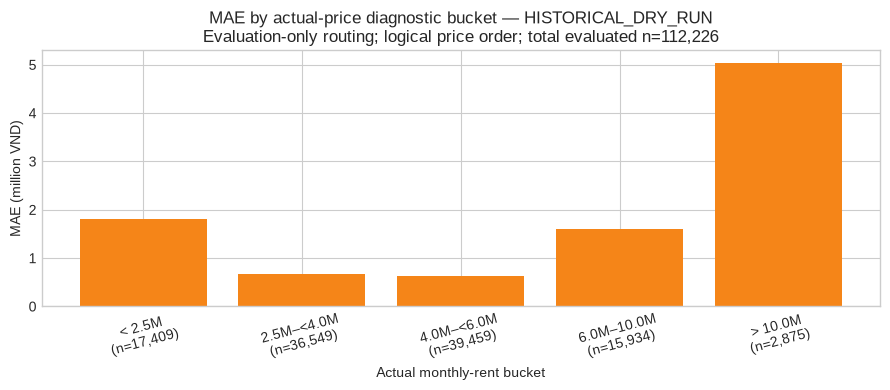

In [12]:
price_diagnostics=price_bucket_diagnostics(evaluation_frame)
display(price_diagnostics)
fig,ax=plt.subplots(figsize=(9,4))
x_labels=[f"{row.Segment}\n(n={row.Rows:,})" for _,row in price_diagnostics.iterrows()]
ax.bar(x_labels,price_diagnostics.MAE/1_000_000,color='#F58518')
ax.set(title=f'MAE by actual-price diagnostic bucket — {VALIDATION_MODE}\nEvaluation-only routing; logical price order; total evaluated n={int(price_diagnostics.Rows.sum()):,}',xlabel='Actual monthly-rent bucket',ylabel='MAE (million VND)')
ax.tick_params(axis='x',rotation=15); plt.tight_layout(); plt.show()

## 14. Area-Bucket Diagnostics

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Area Bucket,Small <15m²,4276,3.810169,2100000.0,2.100819e+06,7.144132e+05,5.007488e+05,-136234.900406
1,Area Bucket,Compact 15–<25m²,28013,24.961239,3200000.0,3.206713e+06,8.054578e+05,5.805578e+05,-34637.512594
2,Area Bucket,Standard 25–<40m²,64856,57.790530,4500000.0,4.499503e+06,1.124657e+06,7.147952e+05,-39746.333044
3,Area Bucket,Large 40–80m²,12902,11.496445,5000000.0,4.999902e+06,1.488415e+06,1.018445e+06,11626.810288
4,Area Bucket,Very large >80m²,2179,1.941618,2900000.0,2.992987e+06,1.531068e+06,9.063630e+05,-408503.870378


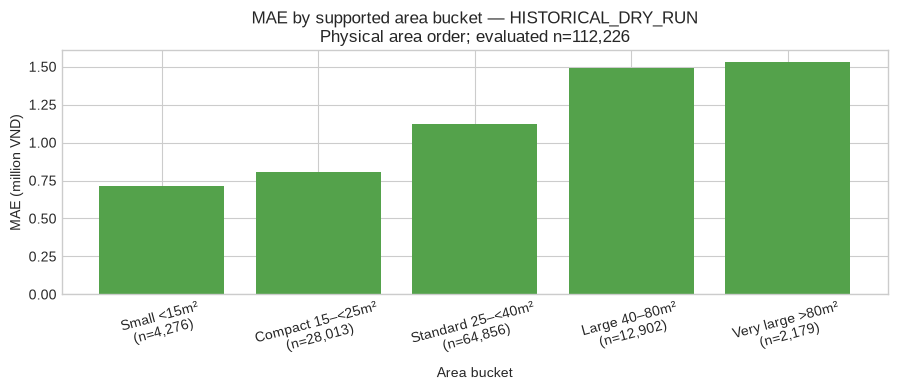

In [13]:
area_diagnostics=area_bucket_diagnostics(evaluation_frame)
display(area_diagnostics)
fig,ax=plt.subplots(figsize=(9,4))
x_labels=[f"{row.Segment}\n(n={row.Rows:,})" for _,row in area_diagnostics.iterrows()]
ax.bar(x_labels,area_diagnostics.MAE/1_000_000,color='#54A24B')
ax.set(title=f'MAE by supported area bucket — {VALIDATION_MODE}\nPhysical area order; evaluated n={int(area_diagnostics.Rows.sum()):,}',xlabel='Area bucket',ylabel='MAE (million VND)')
ax.tick_params(axis='x',rotation=15); plt.tight_layout(); plt.show()

## 15. Source Diagnostics

,Dimension,Segment,Evaluation Rows,Share %,Actual Median,Prediction Median,Evaluation MAE,Evaluation MedianAE,Evaluation Signed Bias,Inference Reference Share %,Inference Shadow Share %,Delta pp
0,Source,phongtro123,69138,61.606045,3500000.0,3.606173e+06,8.505230e+05,5.844273e+05,23099.156552,57.417138,54.510870,-2.906267
1,Source,chothuephongtro,27395,24.410564,5000000.0,5.005291e+06,1.725335e+06,1.458908e+06,-204604.145630,28.606199,27.633924,-0.972275
2,Source,cafeland,9354,8.334967,4000000.0,4.080374e+06,8.993476e+05,6.482343e+05,-95513.720117,7.925332,7.682891,-0.242442
3,Source,mogi,2987,2.661594,3600000.0,3.920232e+06,1.171475e+06,7.306097e+05,163728.442285,2.739969,7.531031,4.791061
4,Source,nhatot,2579,2.298041,3700000.0,3.777605e+06,9.110581e+05,5.783047e+05,-48929.696936,2.586414,2.042366,-0.544048
5,Source,nhatrovn,773,0.688789,4500000.0,4.344151e+06,9.939494e+05,7.092095e+05,-429600.031654,0.724948,0.598918,-0.126030


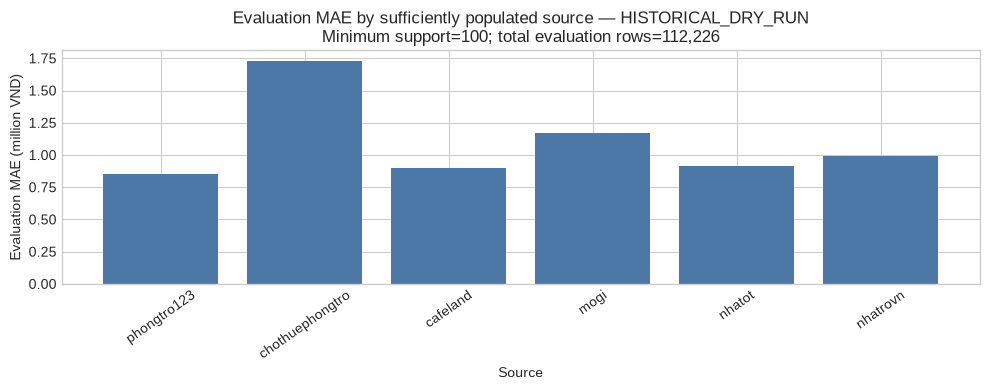

In [14]:
source_metrics=source_diagnostics(evaluation_frame,min_support=MIN_SUPPORT)
source_metrics=source_metrics.merge(source_share[['Category','Reference Share %','Shadow Share %','Delta pp']],left_on='Segment',right_on='Category',how='left').drop(columns=['Category'])
source_metrics=source_metrics.rename(columns={'Reference Share %':'Inference Reference Share %','Shadow Share %':'Inference Shadow Share %','Rows':'Evaluation Rows','MAE':'Evaluation MAE','MedianAE':'Evaluation MedianAE','Signed Bias':'Evaluation Signed Bias'})
display(source_metrics)
fig,ax=plt.subplots(figsize=(10,4))
ax.bar(source_metrics.Segment,source_metrics['Evaluation MAE']/1_000_000,color='#4C78A8')
ax.set(title=f'Evaluation MAE by sufficiently populated source — {VALIDATION_MODE}\nMinimum support={MIN_SUPPORT}; total evaluation rows={int(source_metrics["Evaluation Rows"].sum()):,}',xlabel='Source',ylabel='Evaluation MAE (million VND)')
ax.tick_params(axis='x',rotation=35); plt.tight_layout(); plt.show()

## 16. Location Diagnostics

### High-Support Wards (excluding missing)

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Ward,Phường Tân Hưng,7922,7.058970,5000000.0,5.000002e+06,1.465467e+06,9.999979e+05,-318968.139432
1,Ward,Phường Tân Thuận,5022,4.474899,4600000.0,5.007381e+06,1.483563e+06,9.926190e+05,-335876.865983
2,Ward,Phường Tân Sơn Nhất,3256,2.901288,4500000.0,4.431542e+06,1.137880e+06,6.656789e+05,668.206878
3,Ward,Phường An Hội Tây,3017,2.688325,3500000.0,3.595825e+06,7.906371e+05,5.808189e+05,-29755.827836
4,Ward,Phường Bình Quới,2738,2.439720,4500000.0,4.909732e+06,1.067667e+06,6.852255e+05,253100.170742
5,Ward,Phường Bình Lợi Trung,2531,2.255271,4600000.0,4.879240e+06,9.476557e+05,6.326248e+05,111956.293270
6,Ward,Phường An Nhơn,2491,2.219628,3800000.0,3.822055e+06,8.307411e+05,5.007304e+05,94471.355329
7,Ward,Phường Thông Tây Hội,2178,1.940727,3500000.0,3.630420e+06,8.609020e+05,5.616147e+05,-11709.521190
8,Ward,Phường Tân Sơn Hòa,1976,1.760733,4500000.0,4.824589e+06,1.229690e+06,7.638766e+05,17249.939619
9,Ward,Phường Tây Thạnh,1893,1.686775,3500000.0,3.510173e+06,9.413307e+05,5.518010e+05,3381.484775


### High-Support Districts (excluding missing)

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,District,Quận 7,14285,12.728779,5000000.0,5.000002e+06,1.481049e+06,1.000002e+06,-325709.514292
1,District,Quận Bình Thạnh,10568,9.416713,4600000.0,4.894846e+06,9.811745e+05,6.542192e+05,159297.517983
2,District,Quận Gò Vấp,10333,9.207314,3700000.0,3.832920e+06,9.874012e+05,6.222518e+05,3374.364936
3,District,Quận Tân Bình,9108,8.115766,4500000.0,4.646465e+06,1.218824e+06,7.361234e+05,-32892.018375
4,District,Quận Tân Phú,7194,6.410279,3800000.0,3.903088e+06,1.057753e+06,5.969118e+05,-78940.023866
5,District,Thành phố Thủ Đức,2990,2.664267,3400000.0,3.490320e+06,8.562125e+05,5.892317e+05,75421.254454
6,District,Quận 1,2387,2.126958,5000000.0,5.002502e+06,1.114548e+06,7.191179e+05,-29518.408279
7,District,Quận 10,2302,2.051218,4500000.0,4.833443e+06,1.217065e+06,8.019570e+05,127719.839971
8,District,Quận 8,2049,1.825780,4500000.0,4.285846e+06,1.362003e+06,7.913663e+05,-310107.909592
9,District,Quận Phú Nhuận,1383,1.232335,4800000.0,5.046290e+06,1.105380e+06,7.568716e+05,29072.547224


### Missing Location Diagnostics

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Ward,__MISSING__,37751,33.638373,3800000.0,3.764215e+06,1.117304e+06,769520.112976,-55527.160196
1,District,__MISSING__,42872,38.201486,3500000.0,3.525735e+06,9.131468e+05,639670.340211,-15609.630295


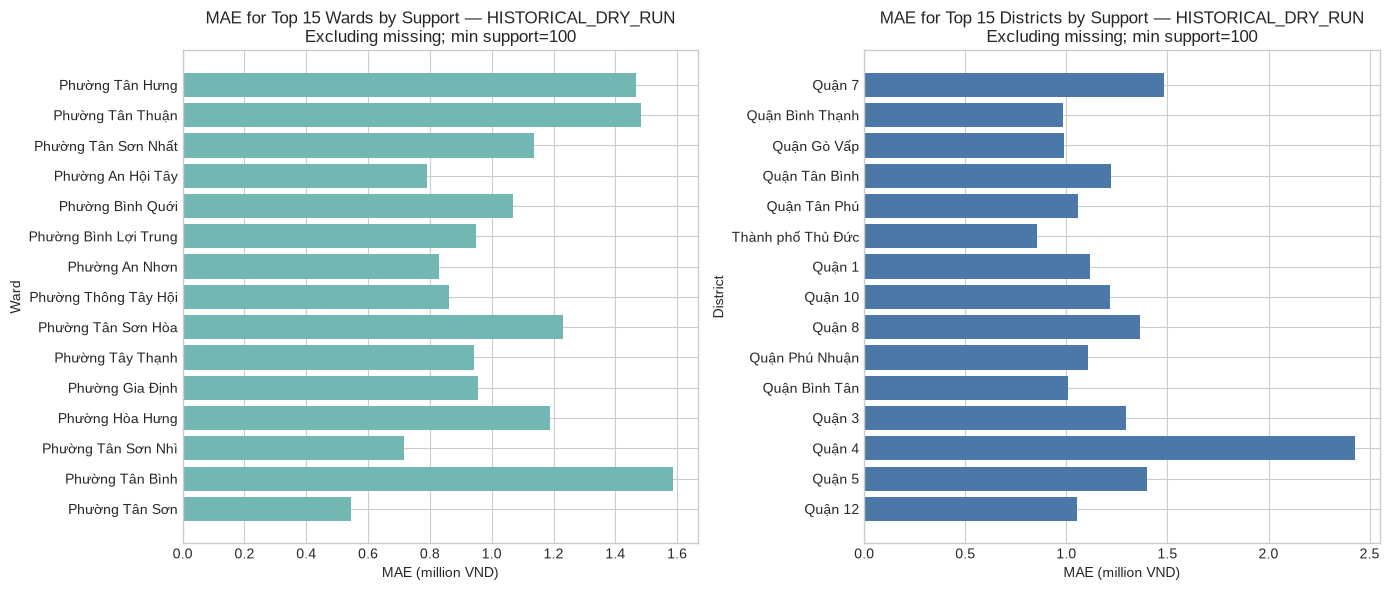

In [15]:
ward_metrics=ward_diagnostics(evaluation_frame,min_support=MIN_SUPPORT,include_missing=False)
district_metrics=district_diagnostics(evaluation_frame,min_support=MIN_SUPPORT,include_missing=False)
missing_loc=missing_location_summary(evaluation_frame)
display(Markdown('### High-Support Wards (excluding missing)')); display(ward_metrics.head(15))
display(Markdown('### High-Support Districts (excluding missing)')); display(district_metrics.head(15))
if len(missing_loc): display(Markdown('### Missing Location Diagnostics')); display(missing_loc)
fig,axes=plt.subplots(1,2,figsize=(14,6))
top_wards=ward_metrics.sort_values('Rows',ascending=False).head(15)
axes[0].barh(top_wards.Segment[::-1],(top_wards.MAE/1_000_000)[::-1],color='#72B7B2')
axes[0].set(title=f'MAE for Top 15 Wards by Support — {VALIDATION_MODE}\nExcluding missing; min support={MIN_SUPPORT}',xlabel='MAE (million VND)',ylabel='Ward')
top_districts=district_metrics.sort_values('Rows',ascending=False).head(15)
axes[1].barh(top_districts.Segment[::-1],(top_districts.MAE/1_000_000)[::-1],color='#4C78A8')
axes[1].set(title=f'MAE for Top 15 Districts by Support — {VALIDATION_MODE}\nExcluding missing; min support={MIN_SUPPORT}',xlabel='MAE (million VND)',ylabel='District')
plt.tight_layout(); plt.show()

## 17. RENT vs UNKNOWN Diagnostics

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Listing Intent,RENT,79323,70.681482,4000000.0,4.029905e+06,1.075997e+06,699168.824326,-89320.265226
1,Listing Intent,UNKNOWN,32903,29.318518,3900000.0,3.939670e+06,1.086445e+06,683300.024659,67300.894174


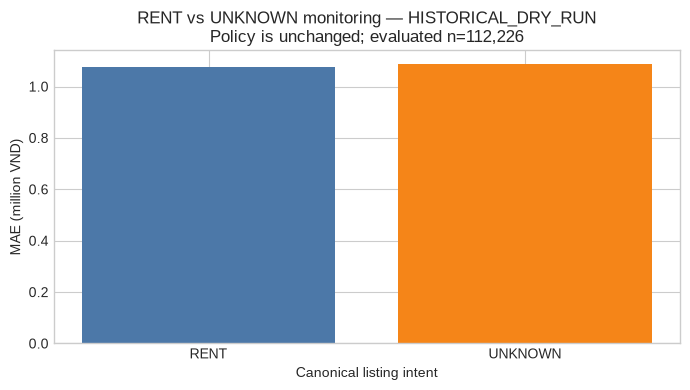

In [16]:
intent_metrics=intent_diagnostics(evaluation_frame)
display(intent_metrics)
fig,ax=plt.subplots(figsize=(7,4)); ax.bar(intent_metrics.Segment,intent_metrics.MAE/1_000_000,color=['#4C78A8','#F58518','#B9B9B9'][:len(intent_metrics)]); ax.set(title=f'RENT vs UNKNOWN monitoring — {VALIDATION_MODE}\nPolicy is unchanged; evaluated n={int(intent_metrics.Rows.sum()):,}',xlabel='Canonical listing intent',ylabel='MAE (million VND)'); plt.tight_layout(); plt.show()

## 18. Temporal Monitoring

,Dimension,Segment,Rows,Share %,Actual Median,Prediction Median,MAE,MedianAE,Signed Bias
0,Observation Date,2026-09-28,19624,17.486144,3600000.0,3.799548e+06,8.204636e+05,5.710982e+05,6.420350e+04
1,Observation Date,2026-09-26,19407,17.292784,4100000.0,4.667374e+06,1.611639e+06,9.953032e+05,-3.717979e+05
2,Observation Date,2026-09-22,16288,14.513571,3500000.0,3.657432e+06,1.031802e+06,7.105493e+05,1.949582e+05
3,Observation Date,2026-09-29,14436,12.863329,3800000.0,3.809506e+06,8.966934e+05,6.142600e+05,-2.885866e+04
4,Observation Date,2026-09-30,12244,10.910128,3600000.0,3.764215e+06,8.923764e+05,6.128919e+05,6.779548e+04
5,Observation Date,2026-09-27,11336,10.101046,3700000.0,3.630420e+06,7.974988e+05,5.298459e+05,-1.656895e+05
6,Observation Date,2026-09-24,8311,7.405592,4500000.0,5.004697e+06,7.294895e+05,5.046968e+05,-3.357452e+04
7,Observation Date,2026-09-23,5123,4.564896,3200000.0,4.998028e+06,2.061302e+06,1.700497e+06,1.175974e+06
8,Observation Date,2026-09-25,4595,4.094417,6500000.0,5.005291e+06,1.451555e+06,1.495303e+06,-1.385486e+06
9,Observation Date,2026-09-21,613,0.546219,3700000.0,3.870330e+06,8.246993e+05,5.872374e+05,1.715752e+04


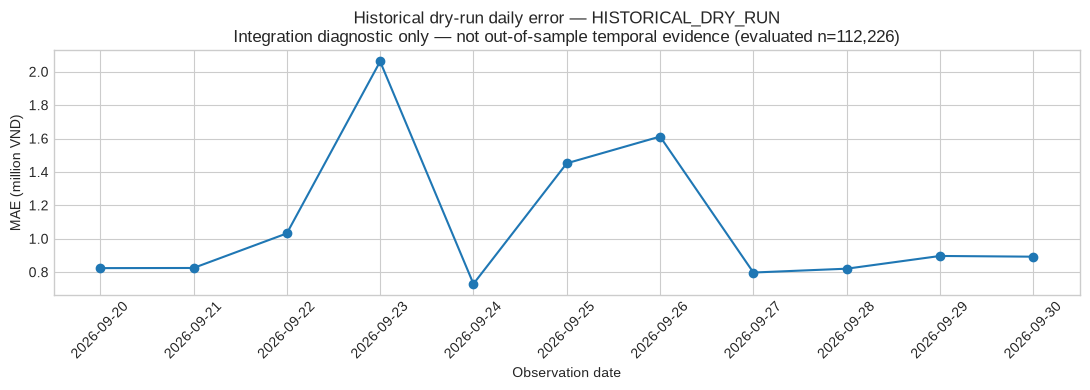

In [17]:
temporal_metrics=temporal_diagnostics(evaluation_frame)
display(temporal_metrics)
temporal_order=temporal_metrics.sort_values('Segment')
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(temporal_order.Segment,temporal_order.MAE/1_000_000,marker='o')
ax.set(title=f'Historical dry-run daily error — {VALIDATION_MODE}\nIntegration diagnostic only — not out-of-sample temporal evidence (evaluated n={int(temporal_order.Rows.sum()):,})',xlabel='Observation date',ylabel='MAE (million VND)')
ax.tick_params(axis='x',rotation=45); plt.tight_layout(); plt.show()

## 19. Prediction Compression Monitoring

,Population,count,min,p01,p25,median,p75,p95,p99,max,P01–P99 Span,Prediction / Actual Span
0,ACTUAL,112226,100000.000000,8.000000e+05,2.900000e+06,4.000000e+06,5.000000e+06,7.000000e+06,1.000000e+07,1.700000e+08,9.200000e+06,0.512697
1,PREDICTION,112226,514492.913765,1.826625e+06,3.412116e+06,4.000362e+06,4.999902e+06,5.637135e+06,6.543435e+06,7.197122e+06,4.716810e+06,0.512697


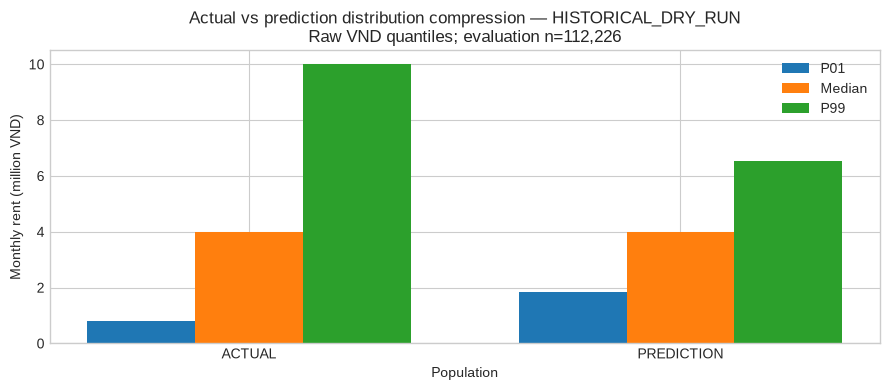

On this observed batch, predictions were concentrated within [1.83M, 6.54M] VND (median 4.00M VND), while actual rent spans [0.80M, 10.00M] VND (median 4.00M VND).


In [18]:
compression_metrics=prediction_compression_report(evaluation_frame)
display(compression_metrics)
fig,ax=plt.subplots(figsize=(9,4)); positions=np.arange(len(compression_metrics)); width=.25
ax.bar(positions-width,compression_metrics.p01/1_000_000,width,label='P01')
ax.bar(positions,compression_metrics['median']/1_000_000,width,label='Median')
ax.bar(positions+width,compression_metrics.p99/1_000_000,width,label='P99')
ax.set(xticks=positions,xticklabels=compression_metrics.Population,title=f'Actual vs prediction distribution compression — {VALIDATION_MODE}\nRaw VND quantiles; evaluation n={len(evaluated):,}',xlabel='Population',ylabel='Monthly rent (million VND)')
ax.legend(); plt.tight_layout(); plt.show()
pred_row=compression_metrics.loc[compression_metrics.Population.eq('PREDICTION')].iloc[0]
act_row=compression_metrics.loc[compression_metrics.Population.eq('ACTUAL')].iloc[0]
print(f"On this observed batch, predictions were concentrated within [{pred_row.p01/1e6:.2f}M, {pred_row.p99/1e6:.2f}M] VND (median {pred_row['median']/1e6:.2f}M VND), while actual rent spans [{act_row.p01/1e6:.2f}M, {act_row.p99/1e6:.2f}M] VND (median {act_row['median']/1e6:.2f}M VND).")

## 20. Production Readiness Gate

,Dimension,Status,Requirement
0,Champion artifact loads,PASS,Required
1,Inference contract valid,PASS,Required
2,No target leakage,PASS,Required
3,Unseen categories handled,PASS,Required
4,Prediction sanity,PASS,Required
5,Drift within configured tolerance,PASS,Provisional monitoring threshold
6,Sufficient shadow sample,PASS,">=1,000 rows (Provisional)"
7,Sufficient future temporal coverage,NOT MET,>=30 future days (Provisional)
8,Core-market error stable,PASS,Provisional monitoring threshold
9,Budget calibration acceptable,NOT MET,Provisional monitoring threshold


,Decision
model_readiness,CANDIDATE
deployment_lifecycle,SHADOW
production_evidence,INSUFFICIENT
recommended_status,CANDIDATE
automatic_production_promotion,DISABLED
threshold_governance,PROVISIONAL_MONITORING_ONLY


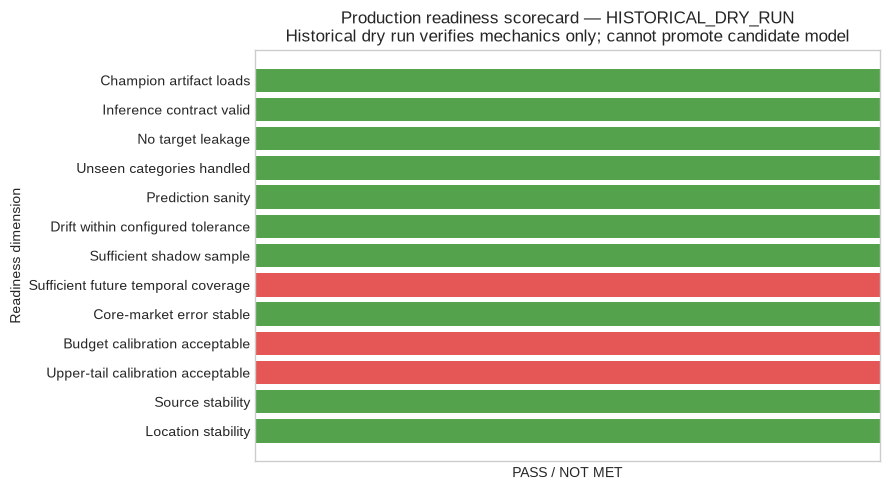

In [19]:
area_row=numeric_drift.iloc[0]
max_source_shift=category_share_drift.loc[category_share_drift.Feature.eq('source_code'),'Delta pp'].abs().max()
max_unseen_pct=category_drift['Unseen Row %'].max()
drift_within_threshold=bool(abs(area_row['Median Shift'])<=max(PROVISIONAL_AREA_MEDIAN_SHIFT_MAX_M2,PROVISIONAL_AREA_MEDIAN_SHIFT_PCT*area_row['Reference Median']) and abs(area_row['Missing Shift pp'])<=PROVISIONAL_AREA_MISSING_SHIFT_PP and max_source_shift<=PROVISIONAL_MAX_SOURCE_SHIFT_PP and max_unseen_pct<=PROVISIONAL_MAX_UNSEEN_CATEGORY_PCT)
def segment_calibrated(table,label):
    row=table.loc[table.Segment.eq(label)]
    return bool(len(row) and abs(row.iloc[0]['Signed Bias'])<=PROVISIONAL_TAIL_BIAS_RATIO_MAX*max(row.iloc[0]['Actual Median'],1))
core_rows=price_diagnostics.loc[price_diagnostics.Segment.isin(['2.5M–<4.0M','4.0M–<6.0M'])].copy()
core_market_error_stable=bool(len(core_rows)==2 and (core_rows.MAE/core_rows['Actual Median'].clip(lower=1)).max()<=PROVISIONAL_CORE_MAE_RATIO_MAX and (core_rows['Signed Bias'].abs()/core_rows['Actual Median'].clip(lower=1)).max()<=PROVISIONAL_CORE_BIAS_RATIO_MAX)
budget_calibration_acceptable=segment_calibrated(price_diagnostics,'< 2.5M')
upper_tail_calibration_acceptable=segment_calibrated(price_diagnostics,'> 10.0M')
source_stability=bool(len(source_metrics) and (source_metrics['Evaluation Signed Bias'].abs()/source_metrics['Actual Median'].clip(lower=1)).max()<=PROVISIONAL_SOURCE_BIAS_RATIO_MAX)
location_stability=bool(len(ward_metrics) and (ward_metrics['Signed Bias'].abs()/ward_metrics['Actual Median'].clip(lower=1)).median()<=PROVISIONAL_LOCATION_BIAS_RATIO_MAX)
observed=pd.to_datetime(population.ready_rows.latest_observed_at,errors='coerce'); temporal_coverage_days=(observed.max()-observed.min()).total_seconds()/86400 if observed.notna().any() else 0
readiness_scorecard,readiness_decision=build_readiness_scorecard(validation_mode=VALIDATION_MODE,sample_rows=len(shadow_predictions),temporal_coverage_days=temporal_coverage_days,artifact_loaded=True,inference_contract_valid=True,no_leakage=TARGET_COLUMN not in X_shadow.columns,unknown_categories_safe=True,prediction_sanity_pass=sanity_checks.Status.eq('PASS').all(),drift_within_threshold=drift_within_threshold,core_market_error_stable=core_market_error_stable,budget_calibration_acceptable=budget_calibration_acceptable,upper_tail_calibration_acceptable=upper_tail_calibration_acceptable,source_stability=source_stability,location_stability=location_stability)
display(readiness_scorecard); display(pd.Series(readiness_decision,name='Decision').to_frame())
readiness_context='Historical dry run verifies mechanics only; cannot promote candidate model' if VALIDATION_MODE=='HISTORICAL_DRY_RUN' else 'Automated checks never promote directly to production'
fig,ax=plt.subplots(figsize=(9,5)); colors=readiness_scorecard.Status.map({'PASS':'#54A24B','NOT MET':'#E45756'}); ax.barh(readiness_scorecard.Dimension[::-1],np.ones(len(readiness_scorecard)),color=colors[::-1]); ax.set(xlim=(0,1),xticks=[],title=f'Production readiness scorecard — {VALIDATION_MODE}\n{readiness_context}',xlabel='PASS / NOT MET',ylabel='Readiness dimension'); plt.tight_layout(); plt.show()
if VALIDATION_MODE=='HISTORICAL_DRY_RUN':
    assert readiness_decision['production_evidence']=='INSUFFICIENT'
    assert readiness_decision['model_readiness']=='CANDIDATE'
    assert readiness_decision['deployment_lifecycle']=='SHADOW'

## 21. Persist Shadow Artifacts

In [20]:
RUN_ID=make_shadow_run_id(VALIDATION_MODE,INFERENCE_TIMESTAMP)
model_eligible_rows=int(evaluation_population.funnel.loc[evaluation_population.funnel.Stage.eq('Final model eligible'),'Rows'].iloc[0])
run_metadata={'run_id':RUN_ID,'model_id':champion.metadata['model_id'],'model_family':champion.metadata['model_family'],'feature_set':champion.metadata['feature_set'],'feature_names':champion.metadata['feature_names'],'target_transform':champion.metadata['target_transform'],'artifact_sha256':champion.metadata['artifact_sha256'],'validation_mode':VALIDATION_MODE,'counts_toward_production_evidence':mode_decision.counts_toward_production,'mode_reason':mode_decision.reason,'silver_sha256':CURRENT_SILVER_SHA256,'data_min_observed_at':mode_decision.min_observed_at,'data_max_observed_at':mode_decision.max_observed_at,'model_lock_evidence_cutoff':mode_decision.evidence_cutoff,'silver_rows':len(silver_df),'inference_ready_rows':len(shadow_predictions),'model_eligible_rows':model_eligible_rows,'evaluation_rows':len(evaluation_frame),'excluded_from_inference_rows':len(silver_df)-len(shadow_predictions),'excluded_from_evaluation_rows':len(silver_df)-model_eligible_rows,'temporal_coverage_days':temporal_coverage_days,'feature_drift_summary':numeric_drift.iloc[0].to_dict(),'category_drift_summary':category_drift.to_dict('records'),'prediction_distribution':prediction_distribution_table.iloc[0].to_dict(),'overall_metrics':overall_metrics.iloc[0].to_dict(),'provisional_monitoring_thresholds':{'minimum_sample_rows':PROVISIONAL_MIN_SAMPLE_ROWS,'minimum_future_days':PROVISIONAL_MIN_FUTURE_DAYS,'area_median_shift':f'<= max({PROVISIONAL_AREA_MEDIAN_SHIFT_MAX_M2}m², {int(PROVISIONAL_AREA_MEDIAN_SHIFT_PCT*100)}% of reference median)','area_missing_shift_pp':PROVISIONAL_AREA_MISSING_SHIFT_PP,'source_share_shift_pp':PROVISIONAL_MAX_SOURCE_SHIFT_PP,'unseen_category_rows_pct':PROVISIONAL_MAX_UNSEEN_CATEGORY_PCT,'budget_and_upper_tail_absolute_bias_pct':int(PROVISIONAL_TAIL_BIAS_RATIO_MAX*100),'source_and_location_bias_pct':int(PROVISIONAL_SOURCE_BIAS_RATIO_MAX*100)},'model_readiness':readiness_decision['model_readiness'],'deployment_lifecycle':readiness_decision['deployment_lifecycle'],'production_evidence':readiness_decision['production_evidence'],'recommended_status':readiness_decision['recommended_status'],'inference_timestamp':INFERENCE_TIMESTAMP}
artifact_tables={'inference_population_funnel':population.funnel,'evaluation_population_funnel':evaluation_population.funnel,'evaluation_exclusion_summary':evaluation_population.exclusion_summary,'schema_validation':population.schema_summary,'numeric_feature_drift':numeric_drift,'category_share_drift':category_share_drift,'category_drift':category_drift,'prediction_distribution':prediction_distribution_table,'prediction_reference_comparison':prediction_reference_comparison,'prediction_sanity':sanity_checks,'overall_metrics':overall_metrics,'price_bucket_metrics':price_diagnostics,'area_bucket_metrics':area_diagnostics,'source_metrics':source_metrics,'ward_metrics':ward_metrics,'district_metrics':district_metrics,'missing_location_metrics':missing_loc,'intent_metrics':intent_metrics,'temporal_metrics':temporal_metrics,'prediction_compression':compression_metrics,'readiness_scorecard':readiness_scorecard}
RUN_DIR=persist_shadow_run(SHADOW_OUTPUT_ROOT,RUN_ID,run_metadata,shadow_output,artifact_tables)
display(pd.DataFrame([{'Artifact':path.name,'Bytes':path.stat().st_size} for path in sorted(RUN_DIR.iterdir()) if path.is_file()]))
display(Markdown(f'Append-only shadow evidence written to `{RUN_DIR}`.'))

,Artifact,Bytes
0,area_bucket_metrics.csv,775
1,category_drift.csv,428
2,category_share_drift.csv,14279
3,district_metrics.csv,2813
4,evaluation_exclusion_summary.csv,157
5,evaluation_population_funnel.csv,453
6,inference_population_funnel.csv,325
7,intent_metrics.csv,344
8,manifest.json,3428
9,missing_location_metrics.csv,341


Append-only shadow evidence written to `/data/projects/roombeacon/source/roombeacon-system/data/modeling/shadow_validation/runs/historical-20261005T065041340462Z`.

## 22. Final Summary

In [21]:
final_summary=pd.Series({'Champion artifact':'PASS','Inference contract':'PASS','Shadow pipeline':'PASS','Validation mode':VALIDATION_MODE,'Historical dry run':'PASS' if VALIDATION_MODE=='HISTORICAL_DRY_RUN' else 'NOT APPLICABLE','Future shadow evidence':'AVAILABLE' if mode_decision.counts_toward_production else 'NOT YET AVAILABLE','Model readiness':readiness_decision['model_readiness'],'Deployment lifecycle':readiness_decision['deployment_lifecycle'],'Production evidence':readiness_decision['production_evidence'],'Recommended status':readiness_decision['recommended_status'],'Silver rows':len(silver_df),'Target-free inference rows':len(shadow_predictions),'Model-evaluation eligible rows':model_eligible_rows,'Evaluated rows':int(overall_metrics.iloc[0]['Rows']),'Model ID':champion.metadata['model_id'],'Run ID':RUN_ID,'Run directory':str(RUN_DIR)},name='Result')
display(final_summary.to_frame())
display(Markdown('**Current evidence remains insufficient for production. Required next evidence: 30–60 days of untouched post-lock multi-crawl observations, with stable source/location error and explicit low-price overprediction and upper-tail underprediction monitoring.**'))

,Result
Champion artifact,PASS
Inference contract,PASS
Shadow pipeline,PASS
Validation mode,HISTORICAL_DRY_RUN
Historical dry run,PASS
Future shadow evidence,NOT YET AVAILABLE
Model readiness,CANDIDATE
Deployment lifecycle,SHADOW
Production evidence,INSUFFICIENT
Recommended status,CANDIDATE


**Current evidence remains insufficient for production. Required next evidence: 30–60 days of untouched post-lock multi-crawl observations, with stable source/location error and explicit low-price overprediction and upper-tail underprediction monitoring.**